In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('data/data_phase1.0.csv')

In [2]:
# get DataFrame for each run_id
run_id01 = df[ df['run_id'] == 1].copy()
run_id02 = df[ df['run_id'] == 2].copy()

In [3]:
# Color definition for 'state' graph
state_colors = {
    'ARMED': 'lightgray',
    'DESCENDING': 'lightblue',
    'PAUSED': 'yellow',
    'LANDED': 'green'
}

In [4]:
"""
    Visualize the time-series changes in atmospheric pressure
    and the transitions between CanSat states(ARMED/DESCENDING/PAUSED/LANDED)
    using a two-panel display

    Parameters
    ----------
    run_df : pd.DataFrame
        Log data for a single run_id. 
        includes columns'timestamp_ms', 'pressure_hpa', 'state'
    title : str
        Run identifier to assign to the graph title (e.g., 'run_id 1')
    state_colors : dict
        A dictionary where state names are the keys and 
        Matplotlib color specifications are the values

    Returns
    -------
    None
        Display the plot only. Returns no value.
"""

def plot_state_transition(run_df, title, state_colors):
    # extract rows which has different status from the previous value
    change_condition = run_df['state'] != run_df['state'].shift(1)
    summary_df = run_df.loc[change_condition, ['timestamp_ms', 'state']].copy()

    # Set end_time_ms
    summary_df['end_time_ms'] = summary_df['timestamp_ms'].shift(-1)
    # for last row(LANDED)
    summary_df['end_time_ms'] = summary_df['end_time_ms'].fillna(run_df['timestamp_ms'].iloc[-1])
    # rename timestamp_ms to start_time_ms
    summary_df = summary_df.rename(columns={'timestamp_ms': 'start_time_ms'})


    # offset time
    offset_time = run_df['timestamp_ms'].iloc[0]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(6, 4), 
        sharex=True, 
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # graph title
    ax1.set_title(title + ': ' + 'State transition due to atmospheric pressure changes')

    # draw a line graph
    ax1.set_ylabel('pressure[hPa]')
    ax1.plot((run_df['timestamp_ms'] - offset_time) / 1000, run_df['pressure_hpa'])

    # draw state transition
    for _, row in summary_df.iterrows():
        ax2.axvspan(
            (row['start_time_ms'] - offset_time) / 1000, 
            (row['end_time_ms'] - offset_time) / 1000, 
            color=state_colors.get(row['state'], 'gray'))

    # setting legend for state transition
    legend_handles = []
    for state_name, color_value in state_colors.items():
        patch = mpatches.Patch(color=color_value, label=state_name)
        legend_handles.append(patch)

    # draw legend
    ax2.legend(
        handles=legend_handles,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        )
    # hide the y-axis tick labels
    ax2.set_yticks([]) 
    ax2.set_xlabel('time[s]')

    plt.show()


    

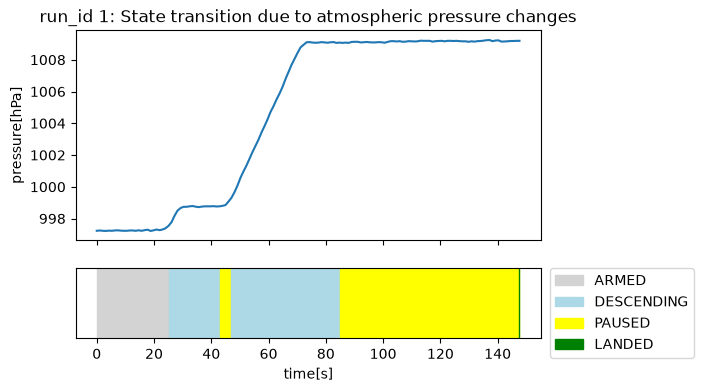

In [5]:
plot_state_transition(run_id01, 'run_id 1', state_colors)

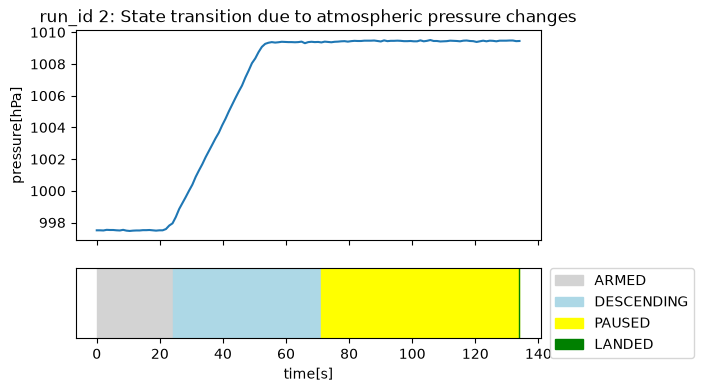

In [6]:
plot_state_transition(run_id02, 'run_id 2', state_colors)